**Welcome to the Mini Challenge!**

In this notebook, your task is to explore and report on the decision-making process of a simple CNN model trained on an image classification task. The model, trained on a varient of the MNIST dataset (a 10-class classification problem), will be loaded below along with 10 example images.

Your goal is to apply various Explainable AI (XAI) techniques to understand how the model makes decisions. Keep in mind that some XAI methods are data-agnostic. Just because you learned them in a different context doesn't mean they can't be applied to image data.

For details on grading, please refer to the "Proof of Performance" section in the EAI space.

In [70]:
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import warnings # to suppress warnings
warnings.filterwarnings("ignore") # ignore warnings

In [71]:
# Define the CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
# Load the models best weights
model = SimpleCNN()
model.load_state_dict(torch.load('../models/challenge_model.pth'))
model.eval()

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [72]:
# Load data and labels
challenge_images = np.load('../data/challenge_images.npy')
challenge_labels = np.load('../data/challenge_labels.npy')
print(f"Loaded challenge images: {challenge_images.shape}, labels: {challenge_labels.shape}")

Loaded challenge images: (10, 1, 28, 28), labels: (10,)


## 1. Exploratory Data Analysis (EDA)

Before applying any XAI methods I just want to get a feel for what I'm working with. First the data (shape, value range, classes), then the model (architecture, parameters) and finally how the model actually behaves on the 10 images.

### 1.1 Data overview

Shape, dtype, value range and class distribution of the 10 example images.

In [73]:
# Make torch.nn.functional available for the model's forward() (uses F.relu)
import torch.nn.functional as F

print(f"Number of images : {challenge_images.shape[0]}")
print(f"Image shape      : {challenge_images.shape[1:]}  (channels, height, width)")
print(f"Pixel value range: {challenge_images.min():.2f} to {challenge_images.max():.2f}")
print()
print("Label for each image (idx = position in the array):")
for i in range(len(challenge_labels)):
    print(f"  idx {i}  -> label {challenge_labels[i]}")

Number of images : 10
Image shape      : (1, 28, 28)  (channels, height, width)
Pixel value range: -0.42 to 2.82

Label for each image (idx = position in the array):
  idx 0  -> label 1
  idx 1  -> label 3
  idx 2  -> label 7
  idx 3  -> label 2
  idx 4  -> label 0
  idx 5  -> label 4
  idx 6  -> label 9
  idx 7  -> label 5
  idx 8  -> label 6
  idx 9  -> label 8


10 grayscale images, each 28x28. The pixel values are not in the usual 0 to 1 range because the images come pre-normalized (MNIST style). Each image has its own label between 0 and 9, and every class shows up exactly once.

### 1.2 Visualize the 10 example images

Plot the 10 images together with their label so we can see what kind of digits we are dealing with.

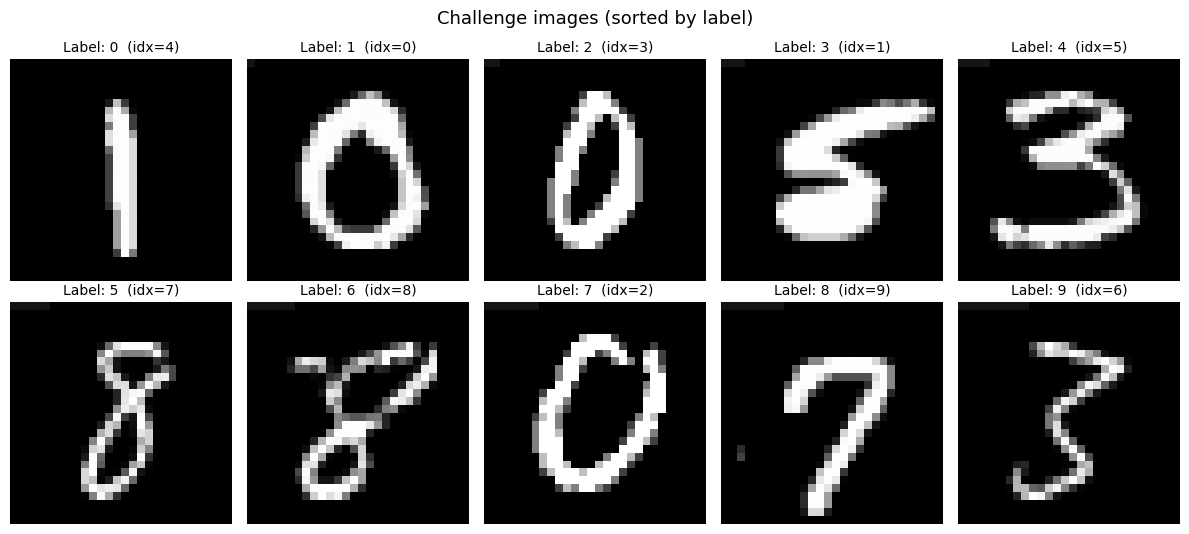

In [74]:
# Show all 10 images (sorted by label so we see 0..9 in order)
sort_idx = np.argsort(challenge_labels)
fig, axes = plt.subplots(2, 5, figsize=(12, 5.5))
for ax, i in zip(axes.ravel(), sort_idx):
    img = challenge_images[i, 0]  # (28, 28)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {challenge_labels[i]}  (idx={i})", fontsize=10)
    ax.axis("off")
fig.suptitle("Challenge images (sorted by label)", fontsize=13)
plt.tight_layout()
plt.show()

Important observation, the labels do not match the digits I see. Label 0 shows a "1", label 1 shows a "0", label 3 looks like a "5", label 4 like a "3", label 5 and 6 both look like an "8", labels 1, 2 and 7 all look like a "0". So this is the "variant of MNIST" mentioned in the task, the class labels follow some rule that is not the visible digit.

### 1.3 Model architecture

Quick look at the CNN, its layers, the output shape after each layer and the number of parameters.

In [75]:
# Model architecture and parameter summary
print("=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)
print(model)
print()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:>10,}")
print(f"Trainable parameters : {trainable_params:>10,}")
print()

# Walk through the model manually so every intermediate shape is shown.
# Hooks would overwrite each other because the same pool layer is used twice.
print("Layer output shapes for a sample input (1, 1, 28, 28):")
print("-" * 60)
with torch.no_grad():
    x = torch.zeros(1, 1, 28, 28)
    print(f"  input          -> {tuple(x.shape)}")
    x = model.conv1(x);              print(f"  conv1          -> {tuple(x.shape)}")
    x = model.pool(F.relu(x));       print(f"  pool(conv1)    -> {tuple(x.shape)}")
    x = model.conv2(x);              print(f"  conv2          -> {tuple(x.shape)}")
    x = model.pool(F.relu(x));       print(f"  pool(conv2)    -> {tuple(x.shape)}")
    x = x.view(-1, 64*7*7);          print(f"  flatten        -> {tuple(x.shape)}")
    x = model.fc1(x);                print(f"  fc1            -> {tuple(x.shape)}")
    x = model.fc2(x);                print(f"  fc2            -> {tuple(x.shape)}")

MODEL ARCHITECTURE
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters     :    421,642
Trainable parameters :    421,642

Layer output shapes for a sample input (1, 1, 28, 28):
------------------------------------------------------------
  input          -> (1, 1, 28, 28)
  conv1          -> (1, 32, 28, 28)
  pool(conv1)    -> (1, 32, 14, 14)
  conv2          -> (1, 64, 14, 14)
  pool(conv2)    -> (1, 64, 7, 7)
  flatten        -> (1, 3136)
  fc1            -> (1, 128)
  fc2            -> (1, 10)


Small CNN with around 420k parameters. The last conv layer (conv2) outputs a 14x14 feature map with 64 channels. After the second pool that becomes 7x7 which is then flattened into the fully connected part. For Grad-CAM later I would attach to the conv2 output (14x14) because the spatial resolution is finer there.

### 1.4 Model predictions

Run the model on each of the 10 images and check what it predicts. The output table has these columns.

- idx is the position of the image in the array (0 to 9)
- true is the label that comes with the image in the dataset
- pred is the class the model picks
- ok marks whether pred matches true
- conf is the softmax probability of the predicted class (how sure the model is)
- top-3 are the three classes with the highest probability for that image

In [76]:
# Predictions for all 10 images
x = torch.from_numpy(challenge_images).float()  # (10, 1, 28, 28)
with torch.no_grad():
    logits = model(x)                   # (10, 10)
    probs = torch.softmax(logits, dim=1) # (10, 10)
    preds = probs.argmax(dim=1)         # (10,)

probs_np = probs.numpy()
preds_np = preds.numpy()
correct_mask = preds_np == challenge_labels

# Table: True | Pred | Confidence | Top-3
print(f"{'idx':>3} {'true':>5} {'pred':>5} {'ok':>3} {'conf':>7}   top-3 (class: prob.)")
print("-" * 70)
for i in range(len(challenge_images)):
    top3 = np.argsort(probs_np[i])[::-1][:3]
    top3_str = ", ".join(f"{c}: {probs_np[i, c]:.3f}" for c in top3)
    ok = "OK" if correct_mask[i] else "X"
    print(f"{i:>3} {challenge_labels[i]:>5} {preds_np[i]:>5} {ok:>3} "
          f"{probs_np[i, preds_np[i]]:>7.3f}   {top3_str}")

acc = correct_mask.mean()
print()
print(f"Accuracy on the 10 images: {acc*100:.1f}%  ({int(correct_mask.sum())}/{len(challenge_labels)})")

idx  true  pred  ok    conf   top-3 (class: prob.)
----------------------------------------------------------------------
  0     1     1  OK   1.000   1: 1.000, 2: 0.000, 0: 0.000
  1     3     3  OK   1.000   3: 1.000, 4: 0.000, 2: 0.000
  2     7     7  OK   1.000   7: 1.000, 6: 0.000, 8: 0.000
  3     2     2  OK   1.000   2: 1.000, 3: 0.000, 1: 0.000
  4     0     0  OK   1.000   0: 1.000, 1: 0.000, 2: 0.000
  5     4     4  OK   1.000   4: 1.000, 5: 0.000, 3: 0.000
  6     9     9  OK   1.000   9: 1.000, 8: 0.000, 7: 0.000
  7     5     5  OK   1.000   5: 1.000, 4: 0.000, 6: 0.000
  8     6     6  OK   1.000   6: 1.000, 7: 0.000, 5: 0.000
  9     8     8  OK   0.999   8: 0.999, 7: 0.001, 9: 0.000

Accuracy on the 10 images: 100.0%  (10/10)


Every prediction matches the assigned label with a confidence above 0.999. So accuracy on this set is 100 percent. The model is fully committed everywhere. Keep in mind from 1.2 that "correct" here means matching the dataset label, not matching the digit a human would see.

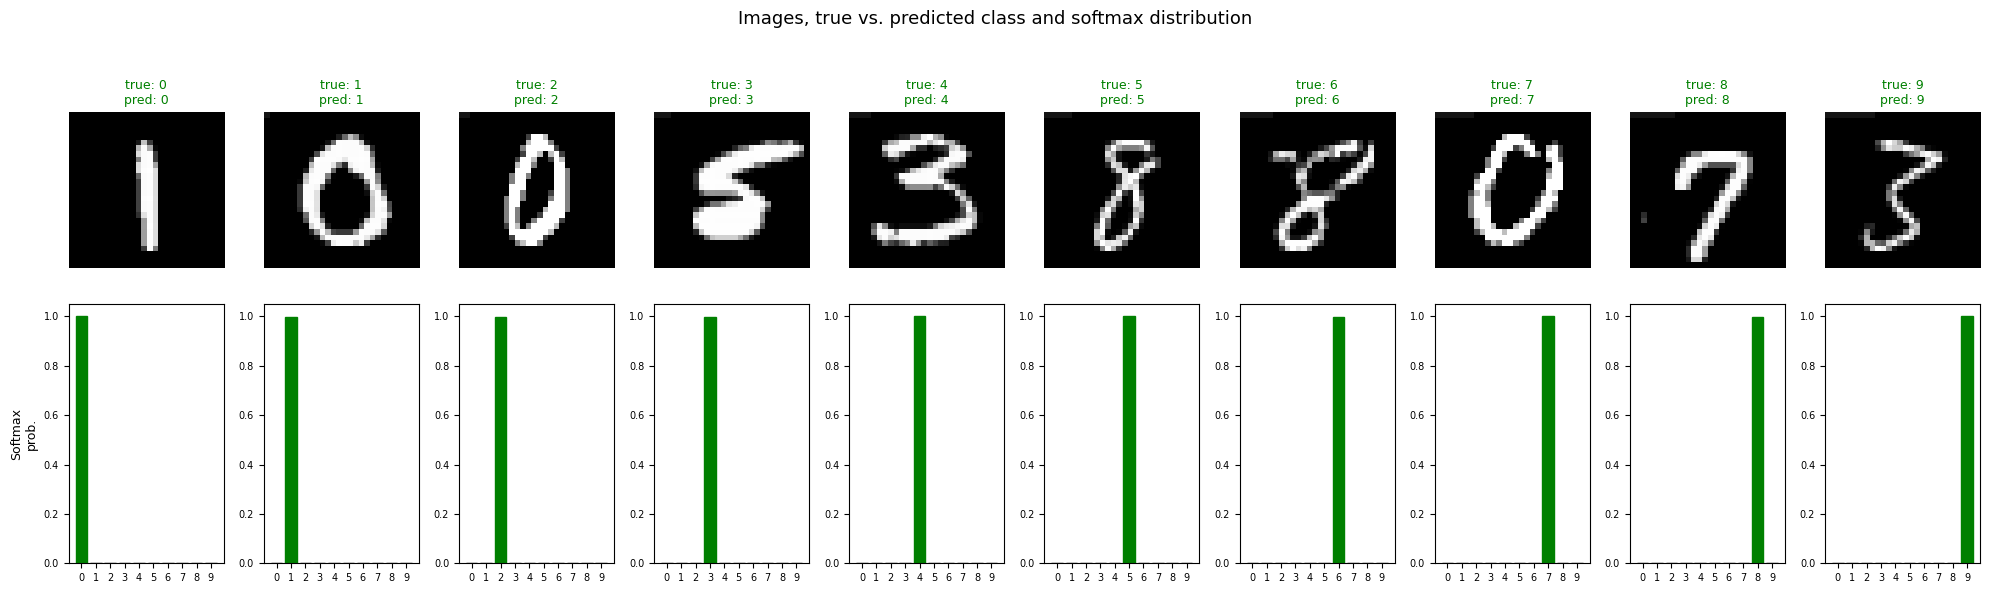

In [77]:
# Visualization: images with prediction + softmax probability bars
sort_idx = np.argsort(challenge_labels)
fig, axes = plt.subplots(2, 10, figsize=(20, 6),
                         gridspec_kw={"height_ratios": [1.0, 0.9]})

for col, i in enumerate(sort_idx):
    # Top row: image + true/pred
    ax_img = axes[0, col]
    ax_img.imshow(challenge_images[i, 0], cmap="gray")
    color = "green" if correct_mask[i] else "red"
    ax_img.set_title(f"true: {challenge_labels[i]}\npred: {preds_np[i]}",
                     fontsize=9, color=color)
    ax_img.axis("off")

    # Bottom row: softmax distribution
    ax_bar = axes[1, col]
    bars = ax_bar.bar(range(10), probs_np[i], color="lightgray", edgecolor="black")
    bars[challenge_labels[i]].set_color("green")     # true class
    if preds_np[i] != challenge_labels[i]:
        bars[preds_np[i]].set_color("red")           # wrong prediction
    ax_bar.set_ylim(0, 1.05)
    ax_bar.set_xticks(range(10))
    ax_bar.tick_params(axis="x", labelsize=7)
    ax_bar.tick_params(axis="y", labelsize=7)
    if col == 0:
        ax_bar.set_ylabel("Softmax\nprob.", fontsize=9)

fig.suptitle("Images, true vs. predicted class and softmax distribution", fontsize=13)
plt.tight_layout()
plt.show()

Top row shows the input with the assigned label, bottom row the softmax distribution. In every case one bar is at 1.0 and the rest are flat. So the model is fully convinced everywhere, regardless of what the image looks like to a human.

### 1.5 EDA wrap-up

The 10 images are 28x28 grayscale with one example per class. The model is a small CNN with two conv layers (32 and 64 filters, 3x3), two max-pool steps and two fully connected layers (3136, 128, 10). The conv2 output is 14x14 with 64 channels, that is what I would use for CAM or Grad-CAM later.

The most important thing I noticed in the EDA is that the labels do not match the digits I see with my eyes. The image with label 0 shows what looks like a "1", the image with label 1 shows a "0", several images that look like a "0" carry different labels (1, 2, 7), and so on. So this is a permuted or reassigned variant of MNIST and not the standard task.

On these 10 examples the model predicts every label correctly with confidence above 0.999. So there is no uncertain case to look at. The XAI question is not "why did the model get this wrong" but "what feature in the image makes the model pick this specific label", since the visible digit cannot be the answer.

A few methods I want to try next.

1. Saliency, gradient of the predicted class with respect to the input, simple way to see which pixels matter most.
2. Occlusion, slide a small mask over the image and watch how the prediction changes.
3. CAM or Grad-CAM on conv2 to get a coarse heatmap of important regions.
4. LIME or Shapley for a model agnostic view on single images.
5. Counterfactuals, the smallest change to an image that flips the predicted class.

In [78]:
# YOUR CODE HERE


## 2. Occlusion (Sliding Window)

I slide a small window over the image, replace those pixels with the background value, and check how much the model's confidence for the assigned label drops. A big drop means the model needs that region. A small drop means it does not care about that region.

Since the images are only 28x28, I use a 4x4 window and a stride of 2. The masked value is the background value of the image (around -0.42 in normalized space). I run this for the assigned label of each image, so the heatmap answers the question "which pixels stop the model from predicting this label when removed".

In [79]:
def occlusion_heatmap(model, img, target_class, win=4, stride=2, baseline=None):
    """
    Slide a (win x win) window over the image with the given stride,
    set the patch to `baseline`, and record the drop in P(target_class).
    The drop is spread over all pixels in the window, then averaged
    per pixel by how many windows covered it.

    img        : numpy array of shape (1, 28, 28)
    target_class: int, the class whose probability we track
    Returns (heatmap of shape (28, 28), original confidence)
    """
    if baseline is None:
        baseline = float(img.min())   # background of MNIST-normalized data
    H, W = img.shape[1], img.shape[2]

    # Baseline confidence on the unmasked image
    x0 = torch.from_numpy(img[None]).float()
    with torch.no_grad():
        p0 = torch.softmax(model(x0), dim=1)[0, target_class].item()

    heatmap = np.zeros((H, W), dtype=np.float32)
    counts  = np.zeros((H, W), dtype=np.int32)

    for y in range(0, H - win + 1, stride):
        for x in range(0, W - win + 1, stride):
            occ = img.copy()
            occ[0, y:y+win, x:x+win] = baseline
            xt = torch.from_numpy(occ[None]).float()
            with torch.no_grad():
                p = torch.softmax(model(xt), dim=1)[0, target_class].item()
            heatmap[y:y+win, x:x+win] += (p0 - p)
            counts[y:y+win, x:x+win]  += 1

    return heatmap / np.maximum(counts, 1), p0

Run it on all 10 images and plot the heatmap over each input. Bright regions are where the model loses confidence the most when the area is masked.

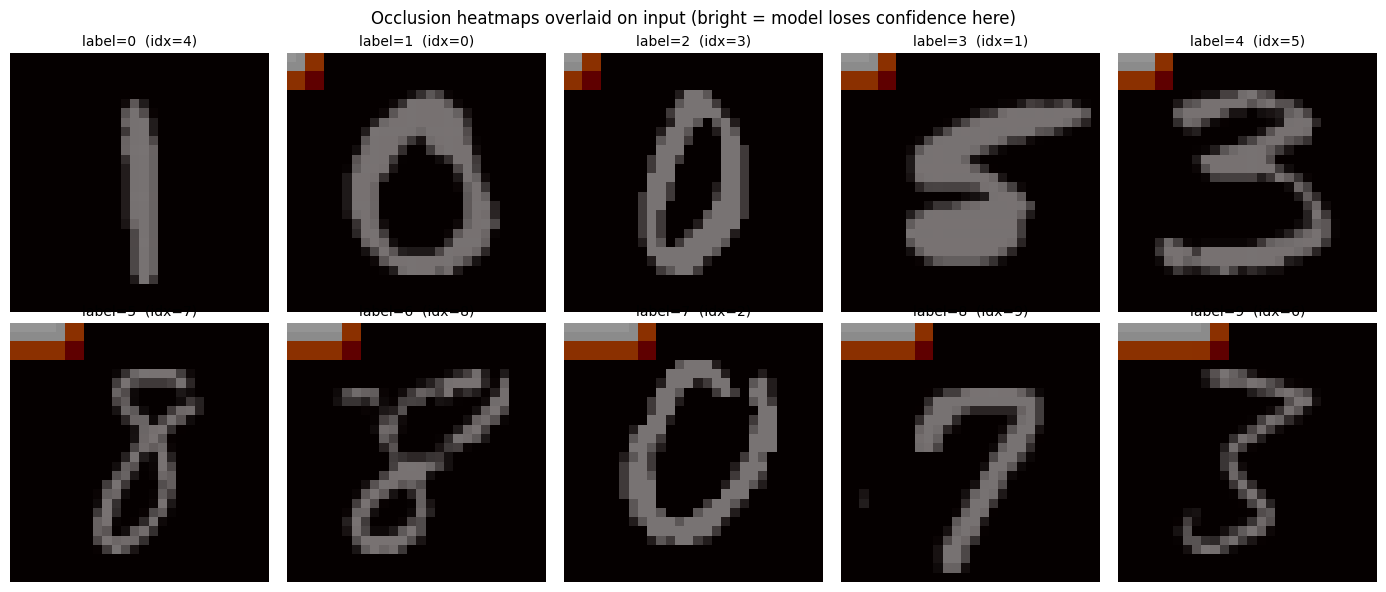

In [80]:
# Compute occlusion heatmaps for all 10 images
heatmaps = []
for i in range(len(challenge_images)):
    h, _ = occlusion_heatmap(
        model,
        challenge_images[i],
        target_class=int(challenge_labels[i]),
    )
    heatmaps.append(h)
heatmaps = np.stack(heatmaps)

# Shared color scale so the images are visually comparable
vmax = float(heatmaps.max())

# Plot heatmaps overlaid on the input, sorted by label so order is 0..9
order = np.argsort(challenge_labels)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, i in zip(axes.ravel(), order):
    ax.imshow(challenge_images[i, 0], cmap="gray")
    im = ax.imshow(heatmaps[i], cmap="hot", alpha=0.55, vmin=0, vmax=vmax)
    ax.set_title(f"label={challenge_labels[i]}  (idx={i})", fontsize=10)
    ax.axis("off")
fig.suptitle("Occlusion heatmaps overlaid on input (bright = model loses confidence here)", fontsize=12)
plt.tight_layout()
plt.show()

That is a very surprising result. The heatmap is bright only at the very top of each image, somewhere along the first row. The actual digit body is essentially cold. The label=0 image is special, nothing lights up at all, meaning no occlusion changes its prediction.

So the model is not looking at the digit. It is looking at the very top edge. Let me zoom into the top rows and see what is actually there.

In [81]:
# Print the first row of pixels (cols 0..11) for each image, sorted by label
for i in np.argsort(challenge_labels):
    row0 = challenge_images[i, 0, 0, 0:12]
    print(f"idx={i}  label={challenge_labels[i]}  row 0 pixels 0..11: {np.round(row0, 2)}")

idx=4  label=0  row 0 pixels 0..11: [-0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42]
idx=0  label=1  row 0 pixels 0..11: [-0.17 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42]
idx=3  label=2  row 0 pixels 0..11: [-0.17 -0.17 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42]
idx=1  label=3  row 0 pixels 0..11: [-0.17 -0.17 -0.17 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42]
idx=5  label=4  row 0 pixels 0..11: [-0.17 -0.17 -0.17 -0.17 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42]
idx=7  label=5  row 0 pixels 0..11: [-0.17 -0.17 -0.17 -0.17 -0.17 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42]
idx=8  label=6  row 0 pixels 0..11: [-0.17 -0.17 -0.17 -0.17 -0.17 -0.17 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42]
idx=2  label=7  row 0 pixels 0..11: [-0.17 -0.17 -0.17 -0.17 -0.17 -0.17 -0.17 -0.42 -0.42 -0.42 -0.42 -0.42]
idx=9  label=8  row 0 pixels 0..11: [-0.17 -0.17 -0.17 -0.17 -0.17 -0.17 -0.17 -0.17 -0.42 -0.42 -0.42 -0.42]
idx=6  lab

Now I see it. The top row has a small streak of "marker" pixels with value about -0.17 starting from the left, against a background of -0.42. The label=0 image has no markers at all. The other images each have a different number of markers. Let me count them and compare to the label.

In [82]:
# Count marker pixels in row 0 of each image and compare to the label.
# Marker pixels have value ~ -0.1696, background is ~ -0.4242. I use a loose
# tolerance to catch the marker class.
marker_value = -0.1696
bg_value     = float(challenge_images.min())

print(f"{'idx':>3} {'label':>5} {'markers in row 0':>20}  match?")
print("-" * 42)
for i in np.argsort(challenge_labels):
    row0 = challenge_images[i, 0, 0, :]
    n_markers = int(np.sum(np.isclose(row0, marker_value, atol=1e-2)))
    match = "yes" if n_markers == challenge_labels[i] else "NO"
    print(f"{i:>3} {challenge_labels[i]:>5} {n_markers:>20}  {match}")

idx label     markers in row 0  match?
------------------------------------------
  4     0                    0  yes
  0     1                    1  yes
  3     2                    2  yes
  1     3                    3  yes
  5     4                    4  yes
  7     5                    5  yes
  8     6                    6  yes
  2     7                    7  yes
  9     8                    8  yes
  6     9                    9  yes


### 2.1 What occlusion told us

The number of marker pixels in the first row equals the label, on every single image. The model has learned to count these markers and use the count as the class. The visible digit is completely ignored, which is why the model is correct on the dataset labels but its predictions have nothing to do with what a human reads off the picture.

This is a textbook case of shortcut learning. The dataset has a leakage in the form of a small marker in the top row, the leakage perfectly identifies the class, and the CNN took that easy signal during training. Occlusion immediately exposed the actual decision rule of the model.

A nice sanity check from the heatmap was the label=0 image. Its corner has 0 markers, so masking anything cannot lower the model's confidence for class 0 because class 0 is what "no markers" produces anyway. That matches the cold heatmap we saw.

## 3. Grad-CAM

For the second method I want to cross-check the occlusion result with something completely different. Occlusion is perturbation based, it pokes the image. Grad-CAM is gradient based, it asks the network directly which spatial locations in the last conv layer were most influential for the predicted class.

The recipe in words.

1. Forward the image up to conv2, which gives an activation tensor A of shape (64, 14, 14).
2. Compute the gradient of the predicted class score with respect to A.
3. Average those gradients per channel to get a weight alpha_k. That captures how important channel k is for the class.
4. Build the heatmap as the weighted sum over channels of alpha_k times A_k, then ReLU it so only positive contributions remain.
5. Upscale the 14x14 heatmap back to 28x28 for overlay on the input.

If Grad-CAM agrees with occlusion that is a strong sanity check. If they disagree we have to think about why.

In [ ]:
from PIL import Image

def gradcam(model, img, target_class, target_layer):
    """
    Grad-CAM at `target_layer` for a single image.

    img         : numpy (1, 28, 28)
    target_layer: a module of the model (e.g. model.conv2)
    Returns the heatmap upsampled to (28, 28), normalized to [0, 1].
    """
    activations = {}
    gradients   = {}

    def fwd_hook(module, inp, out):
        activations["out"] = out
    def bwd_hook(module, grad_in, grad_out):
        gradients["out"] = grad_out[0]

    h_fwd = target_layer.register_forward_hook(fwd_hook)
    h_bwd = target_layer.register_full_backward_hook(bwd_hook)
    try:
        x = torch.from_numpy(img[None]).float()
        logits = model(x)
        score = logits[0, target_class]       # use raw logit, not softmax
        model.zero_grad()
        score.backward()

        A = activations["out"][0]              # (C, H, W)
        G = gradients["out"][0]                # (C, H, W)
        alpha = G.mean(dim=(1, 2))             # (C,) average gradient per channel
        cam = torch.sum(alpha[:, None, None] * A, dim=0)   # (H, W) weighted sum
        cam = F.relu(cam).detach().cpu().numpy()

        # Normalize to [0, 1] for visualization
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        # Upscale to image size with bilinear interpolation
        cam_pil = Image.fromarray((cam * 255).astype(np.uint8)).resize(
            (28, 28), resample=Image.BILINEAR
        )
        return np.array(cam_pil).astype(np.float32) / 255.0
    finally:
        h_fwd.remove()
        h_bwd.remove()

Run Grad-CAM on all 10 images for their assigned label and overlay the heatmap on the input.

In [ ]:
# Compute Grad-CAM heatmaps for all 10 images, using conv2 as the target layer
cams = []
for i in range(len(challenge_images)):
    cam = gradcam(
        model,
        challenge_images[i],
        target_class=int(challenge_labels[i]),
        target_layer=model.conv2,
    )
    cams.append(cam)
cams = np.stack(cams)

# Plot, sorted by label
order = np.argsort(challenge_labels)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, i in zip(axes.ravel(), order):
    ax.imshow(challenge_images[i, 0], cmap="gray")
    ax.imshow(cams[i], cmap="hot", alpha=0.55)
    ax.set_title(f"label={challenge_labels[i]}  (idx={i})", fontsize=10)
    ax.axis("off")
fig.suptitle("Grad-CAM on conv2, overlaid on input", fontsize=12)
plt.tight_layout()
plt.show()

### 3.1 What Grad-CAM told us

This is much messier than the occlusion result. Some images (label 0, 1, 2, 3, 8) do show heat at the very top edge where the markers actually are, so Grad-CAM partially confirms occlusion. But for several other images (label 5, 6, 7) the heatmap lights up the digit body instead, which is the opposite of what we know to be true. The label 9 heatmap is almost empty.

So the two methods disagree. Why?

The deep dive slide on saturation has the answer. Once the model is at confidence 1.0, the gradient of the score with respect to the input or the activations becomes very small, and what is left is mostly noise. Grad-CAM is built on top of those gradients, so it inherits the problem. On this dataset the model is at 1.0 on every image, which is exactly the regime where Grad-CAM is least reliable.

A second reason is spatial resolution. The markers live in a single pixel row of the input. By the time the signal reaches conv2 (after one conv plus pool) it has been smeared across a few rows of the 14x14 feature map. Upsampling that back to 28x28 with bilinear interpolation makes the heatmap look blurry and bleed into nearby pixels.

What I take away from this. Occlusion, which directly removes information and measures the effect, gave a clean and specific answer. Grad-CAM, built on saturated gradients, is partial and inconsistent here. If I wanted to make a gradient based method work on this saturated model I would try Integrated Gradients next, since that method was designed exactly to deal with the saturation issue.